In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('EV_Dataset.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (96845, 8)
Columns: ['Year', 'Month_Name', 'Date', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type', 'EV_Sales_Quantity']
     Year Month_Name      Date           State         Vehicle_Class  \
0  2014.0        jan  1/1/2014  Andhra Pradesh       ADAPTED VEHICLE   
1  2014.0        jan  1/1/2014  Andhra Pradesh  AGRICULTURAL TRACTOR   
2  2014.0        jan  1/1/2014  Andhra Pradesh             AMBULANCE   
3  2014.0        jan  1/1/2014  Andhra Pradesh   ARTICULATED VEHICLE   
4  2014.0        jan  1/1/2014  Andhra Pradesh                   BUS   

  Vehicle_Category Vehicle_Type  EV_Sales_Quantity  
0           Others       Others                0.0  
1           Others       Others                0.0  
2           Others       Others                0.0  
3           Others       Others                0.0  
4              Bus          Bus                0.0  


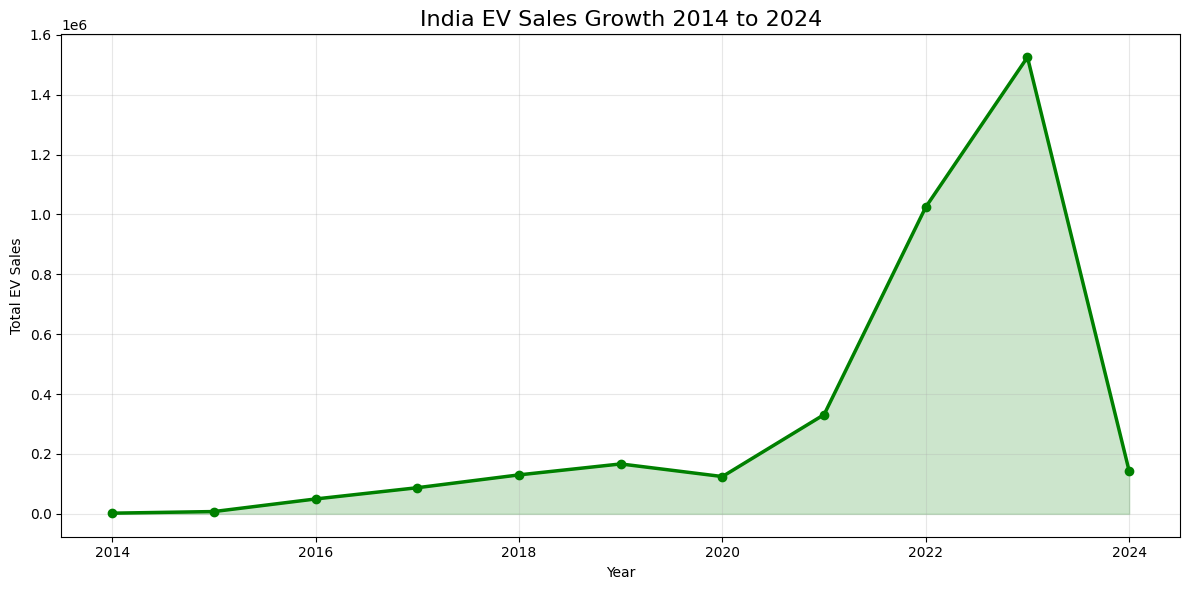

Chart 1 saved!


In [3]:
yearly = df.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(yearly['Year'], yearly['EV_Sales_Quantity'],
         color='green', linewidth=2.5, marker='o', markersize=6)
plt.fill_between(yearly['Year'], yearly['EV_Sales_Quantity'],
                 alpha=0.2, color='green')
plt.title('India EV Sales Growth 2014 to 2024', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Total EV Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_yearly_growth.png', dpi=150)
plt.show()
print("Chart 1 saved!")

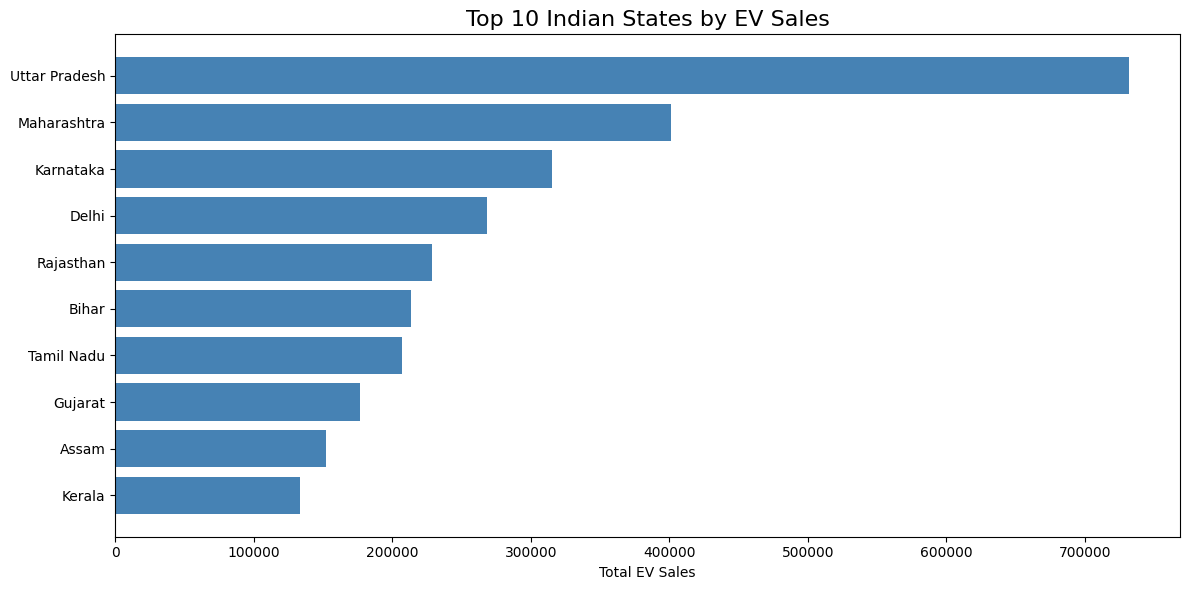

Chart 2 saved!


In [4]:
state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().reset_index()
state_sales = state_sales.sort_values('EV_Sales_Quantity', ascending=True).tail(10)

plt.figure(figsize=(12, 6))
plt.barh(state_sales['State'], state_sales['EV_Sales_Quantity'],
         color='steelblue')
plt.title('Top 10 Indian States by EV Sales', fontsize=16)
plt.xlabel('Total EV Sales')
plt.tight_layout()
plt.savefig('chart2_top_states.png', dpi=150)
plt.show()
print("Chart 2 saved!")

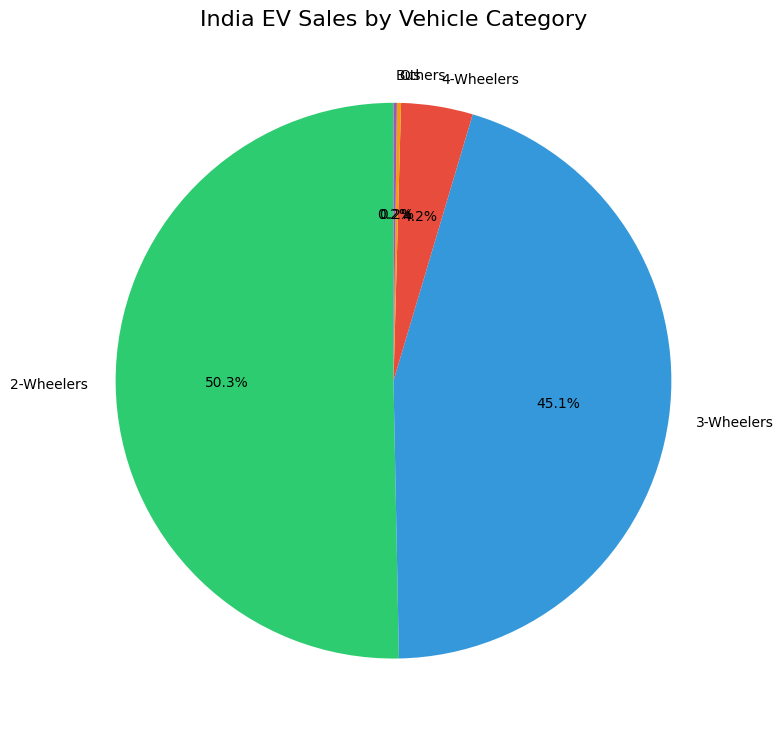

Chart 3 saved!


In [5]:
category_sales = df.groupby('Vehicle_Category')['EV_Sales_Quantity'].sum().reset_index()
category_sales = category_sales.sort_values('EV_Sales_Quantity', ascending=False)

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

plt.figure(figsize=(8, 8))
plt.pie(category_sales['EV_Sales_Quantity'],
        labels=category_sales['Vehicle_Category'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)
plt.title('India EV Sales by Vehicle Category', fontsize=16)
plt.tight_layout()
plt.savefig('chart3_vehicle_category.png', dpi=150)
plt.show()
print("Chart 3 saved!")

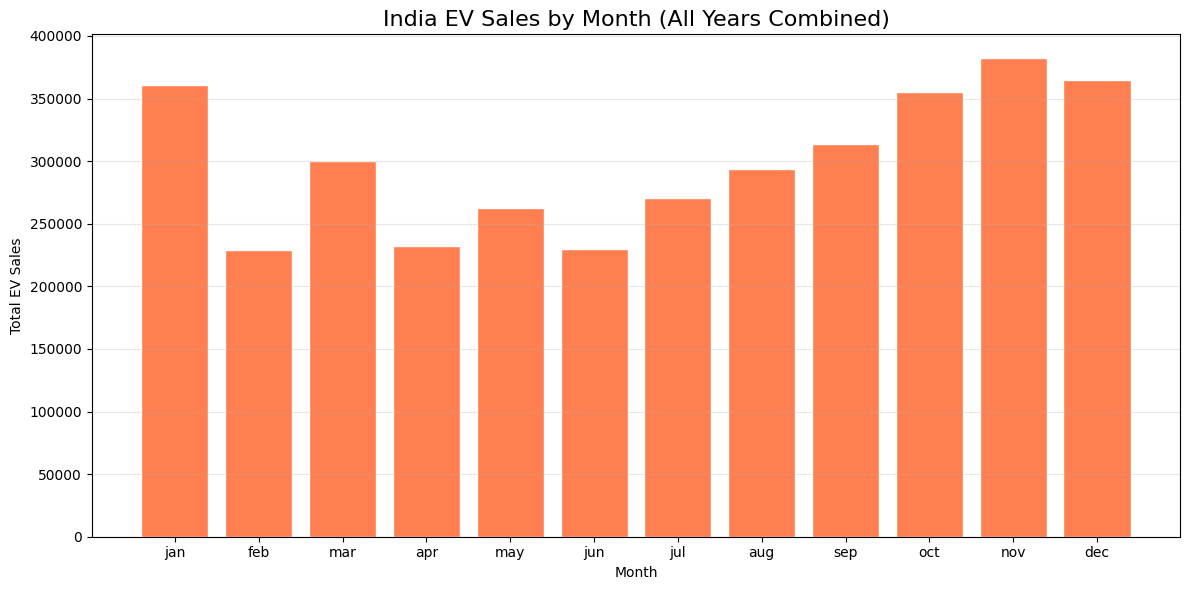

Chart 4 saved!


In [6]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

monthly = df.groupby('Month_Name')['EV_Sales_Quantity'].sum().reset_index()
monthly['Month_Name'] = pd.Categorical(monthly['Month_Name'],
                                        categories=month_order,
                                        ordered=True)
monthly = monthly.sort_values('Month_Name')

plt.figure(figsize=(12, 6))
plt.bar(monthly['Month_Name'], monthly['EV_Sales_Quantity'],
        color='coral', edgecolor='white')
plt.title('India EV Sales by Month (All Years Combined)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total EV Sales')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart4_monthly_sales.png', dpi=150)
plt.show()
print("Chart 4 saved!")

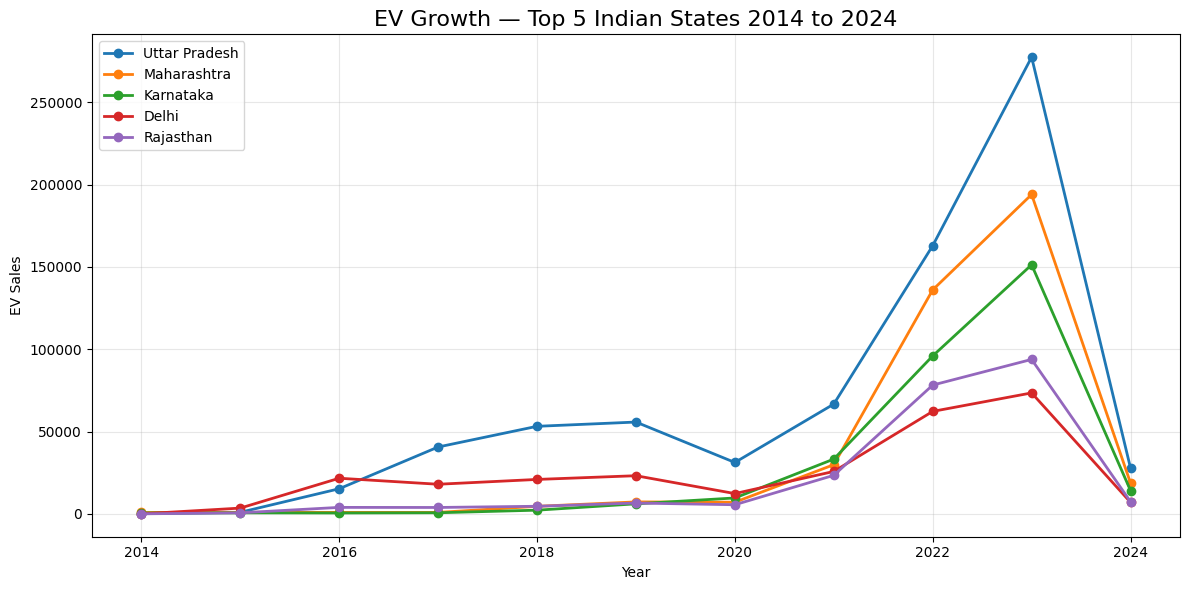

Chart 5 saved!


In [7]:
top5_states = ['Uttar Pradesh', 'Maharashtra',
               'Karnataka', 'Delhi', 'Rajasthan']

state_year = df[df['State'].isin(top5_states)].groupby(
    ['Year', 'State'])['EV_Sales_Quantity'].sum().reset_index()

plt.figure(figsize=(12, 6))
for state in top5_states:
    data = state_year[state_year['State'] == state]
    plt.plot(data['Year'], data['EV_Sales_Quantity'],
             marker='o', linewidth=2, label=state)

plt.title('EV Growth — Top 5 Indian States 2014 to 2024', fontsize=16)
plt.xlabel('Year')
plt.ylabel('EV Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart5_top5_states_growth.png', dpi=150)
plt.show()
print("Chart 5 saved!")